# Lab: Regression Analysis

### Before you start:

* Read the README.md file
* Comment as much as you can and use the resources (README.md file) 

Happy learning!

## Challenge 1
I work at a coding bootcamp, and I have developed a theory that the younger my students are, the more often they are late to class. In order to test my hypothesis, I have collected some data in the following table:

| StudentID | Age | Tardies |
|--------|-----|------------|
| 1      | 17  | 10         |
| 2      | 51  | 1          |
| 3      | 27  | 5          |
| 4      | 21  | 9         |
| 5      | 36  |  4         |
| 6      | 48  |  2         |
| 7      | 19  |  9         |
| 8      | 26  | 6          |
| 9      | 54  |  0         |
| 10     | 30  |  3         |

In [11]:
import pandas as pd
import numpy as np
import plotly.express as px
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

Use this command to create a dataframe with the data provided in the table. 
~~~~
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})
~~~~

In [9]:
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})

Draw a dispersion diagram (scatter plot) for the data.

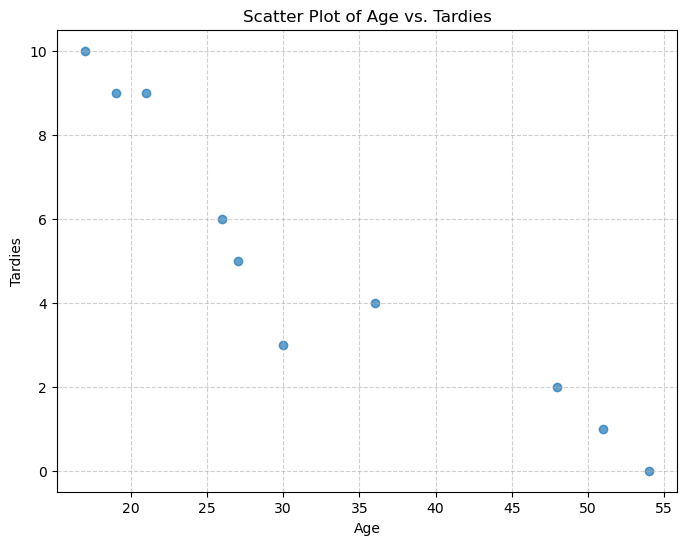

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(student_data['Age'], student_data['Tardies'], alpha=0.7)
plt.title('Scatter Plot of Age vs. Tardies')
plt.xlabel('Age')
plt.ylabel('Tardies')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


Do you see a trend? Can you make any hypotheses about the relationship between age and number of tardies?

There is a trend where the older the student is the less tardy they are. 

Calculate the covariance and correlation of the variables in your plot. What is the difference between these two measures? Compare their values. What do they tell you in this case? Add your responses as comments after your code.

In [17]:
covariance = student_data['Age'].cov(student_data['Tardies'])
correlation = student_data['Age'].corr(student_data['Tardies'])
print(f"Covariance: {covariance}")
# Since the covariance is -45.5667 we can asume that there's an inverse relationship between age and tardies. 
print(f"Correlation: {correlation}")
# Since the correlation is -0.9391 we can asume that there's a strong negative linear relationship between age and tardies.

Covariance: -45.56666666666666
Correlation: -0.9391626886887122


Build a regression model for this data. What will be your outcome variable? What type of regression are you using? Add your responses as comments after your code.

In [23]:

X = np.array(student_data['Age']).reshape(-1, 1)  # Predictor variable
y = student_data['Tardies']  # Outcome variable

# I'm going to use a linear regression because of what I saw in the scatter plot. 
model = LinearRegression()
model.fit(X, y)

# Building parameters. 
slope = model.coef_[0]
intercept = model.intercept_
print(f"Regression equation: Tardies = {slope:.2f} * Age + {intercept:.2f}")

Regression equation: Tardies = -0.24 * Age + 12.89


Plot your regression model on your scatter plot.

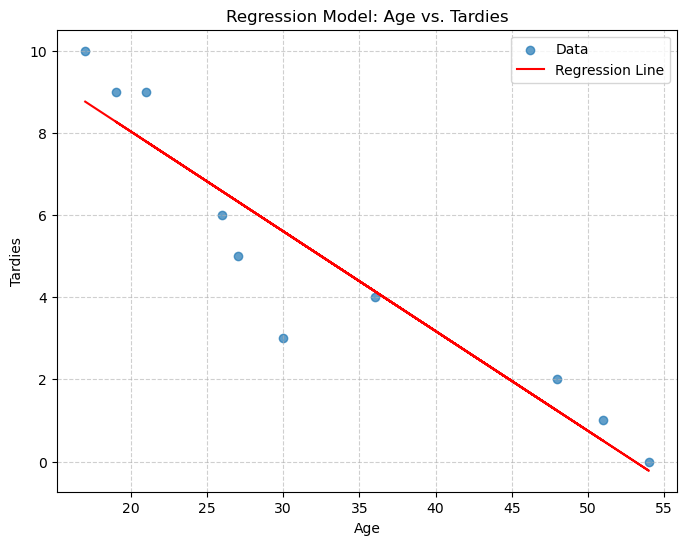

In [21]:
# Plotting the line to be able to see it. 
plt.figure(figsize=(8, 6))
plt.scatter(student_data['Age'], student_data['Tardies'], alpha=0.7, label='Data')
plt.plot(student_data['Age'], model.predict(X), color='red', label='Regression Line')
plt.title('Regression Model: Age vs. Tardies')
plt.xlabel('Age')
plt.ylabel('Tardies')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Interpret the results of your model. What can conclusions can you draw from your model and how confident in these conclusions are you? Can we say that age is a good predictor of tardiness? Add your responses as comments after your code.

So, when we made the first scatter plot we could already see that the slope of the regression is negative. This means that as age increases tardies decreased. Based on the data presented, we can safely assume that age is a good predictor of tardiness. 

## Challenge 2
For the second part of this lab, we will use the vehicles.csv data set. You can find a copy of the dataset in the git hub folder. This dataset includes variables related to vehicle characteristics, including the model, make, and energy efficiency standards, as well as each car's CO2 emissions. As discussed in class the goal of this exercise is to predict vehicles' CO2 emissions based on several independent variables. 

In [13]:
# Import any libraries you may need & the data
vehicles = pd.read_csv("vehicles.csv")

Let's use the following variables for our analysis: Year, Cylinders, Fuel Barrels/Year, Combined MPG, and Fuel Cost/Year. We will use 'CO2 Emission Grams/Mile' as our outcome variable. 

Calculate the correlations between each of these variables and the outcome. Which variable do you think will be the most important in determining CO2 emissions? Which provides the least amount of helpful information for determining CO2 emissions? Add your responses as comments after your code.

In [30]:
selected_columns = [
    'Year', 
    'Cylinders', 
    'Fuel Barrels/Year', 
    'Combined MPG', 
    'Fuel Cost/Year', 
    'CO2 Emission Grams/Mile'
]
vehicles = vehicles[selected_columns]

correlations = vehicles.corr()['CO2 Emission Grams/Mile'].sort_values(ascending=False)

correlations

# Fuel Barrels/Year has the highest correlation 0.986 with CO2 emissions so we can assume it is the strongest predictor of CO2 emissions.
# Combined MPG has a negative correlation -0.926, indicating that vehicles with better fuel efficiency (higher MPG) produce significantly fewer CO2 emissions.

CO2 Emission Grams/Mile    1.000000
Fuel Barrels/Year          0.986189
Fuel Cost/Year             0.930865
Cylinders                  0.752393
Year                      -0.222300
Combined MPG              -0.926229
Name: CO2 Emission Grams/Mile, dtype: float64

Build a regression model for this data. What type of regression are you using? Add your responses as comments after your code.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

#Redefining features and target variables
features = ['Engine Displacement', 'Cylinders', 'City MPG', 'Highway MPG', 'Combined MPG']
target = 'CO2 Emission Grams/Mile'

# Correcting the use of pd.to_numeric
for col in features + [target]:
    vehicles[col] = pd.to_numeric(vehicles[col], errors='coerce')  # Convert to numeric, coercing errors to NaN

# Dropping rows with missing values in the specified columns
vehicles_cleaned = vehicles.dropna(subset=features + [target])

# Splitting the cleaned data into training and testing sets
X = vehicles_cleaned[features]
y = vehicles_cleaned[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Using a linear regression to show the correlation. 
model = LinearRegression()
model.fit(X_train, y_train)

# Making predictions and evaluating the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, r2

(1331.1805836594267, 0.9056333049149969)

Print your regression summary, and interpret the results. What are the most important varibles in your model and why? What can conclusions can you draw from your model and how confident in these conclusions are you? Add your responses as comments after your code.

In [21]:
import statsmodels.api as sm

X_with_constant = sm.add_constant(X_train)

model_stats = sm.OLS(y_train, X_with_constant).fit()
summary = model_stats.summary()

print(summary)

# The R-squared value 0.91 indicates that 91% of the variance in the CO2 emissions is explained by the model.
# Positive coefficients indicate that an increase in the predictor leads to higher CO2 emissions, while negative coefficients indicate a decrease.
# Significant variables will have a more reliable impact on the target variable.
# Fuel efficiency metrics like 'Combined MPG' are likely to have a significant inverse relationship with CO2 emissions.
# Larger engines (higher displacement) contribute to higher CO2 emissions.



                               OLS Regression Results                              
Dep. Variable:     CO2 Emission Grams/Mile   R-squared:                       0.905
Model:                                 OLS   Adj. R-squared:                  0.905
Method:                      Least Squares   F-statistic:                 5.479e+04
Date:                     Mon, 20 Jan 2025   Prob (F-statistic):               0.00
Time:                             22:52:51   Log-Likelihood:            -1.4444e+05
No. Observations:                    28761   AIC:                         2.889e+05
Df Residuals:                        28755   BIC:                         2.889e+05
Df Model:                                5                                         
Covariance Type:                 nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

## Bonus Challenge: Error Analysis

I am suspicious about the last few parties I have thrown: it seems that the more people I invite the more people are unable to attend. To know if my hunch is supported by data, I have decided to do an analysis. I have collected my data in the table below, where X is the number of people I invited, and Y is the number of people who attended. 

|  X |  Y |
|----|----|
| 1  |  1 |
| 3  |  2 |
| 4  |  4 |
| 6  |  4 |
| 8  |  5 |
| 9  |  7 |
| 11 |  8 |
| 14 |  13 |

We want to know if the relationship modeled by the two random variables is linear or not, and therefore if it is appropriate to model it with a linear regression. 
First, build a dataframe with the data. 

In [25]:
party_invites = {
    "X": [1, 3, 4, 6, 8, 9, 11, 14],
    "Y": [1, 2, 4, 4, 5, 7, 8, 13],
}
df = pd.DataFrame(party_invites)

Draw a dispersion diagram (scatter plot) for the data, and fit a regression line.

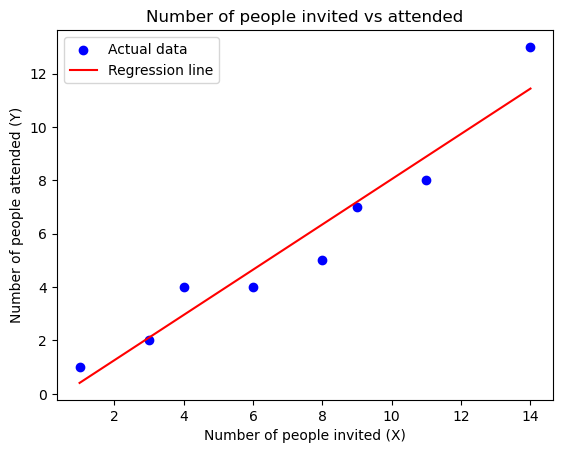

(0.8712121212121214,
 0.9316696375519905,
 0.8484848484848485,
 -0.43939393939393945)

In [27]:
X = df[['X']]
y = df['Y']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

plt.scatter(df['X'], df['Y'], label="Actual data", color='blue')
plt.plot(df['X'], y_pred, label="Regression line", color='red')
plt.xlabel("Number of people invited (X)")
plt.ylabel("Number of people attended (Y)")
plt.title("Number of people invited vs attended")
plt.legend()
plt.show()

mse, r2, model.coef_[0], model.intercept_

What do you see? What does this plot tell you about the likely relationship between the variables? Print the results from your regression.

For each additional person invited, approximately 0.85 more people are expected to attend.

There is a strong positive relationship between the number of people invited and those attending, as shown by the high R² score.

Do you see any problematic points, or outliers, in your data? Remove these points and recalculate your regression. Print the new dispersion diagram with your new model and the results of your model. 

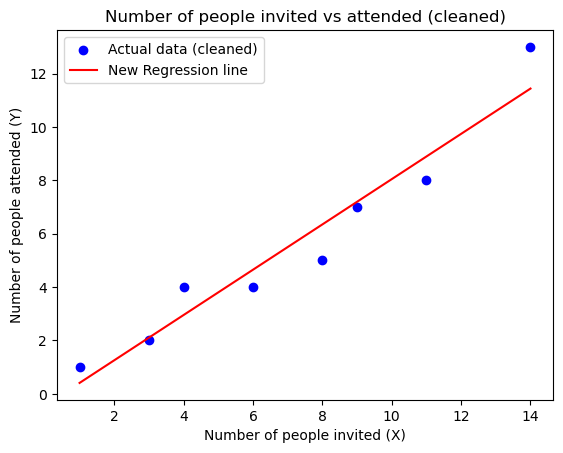

(Empty DataFrame
 Columns: [X, Y]
 Index: [],
 0.8712121212121214,
 0.9316696375519905,
 0.8484848484848485,
 -0.43939393939393945)

In [29]:
residuals = y - y_pred
threshold = 2 * np.std(residuals) 

# Identifying outliers
outliers = df[np.abs(residuals) > threshold]

# Removing outliers from the dataset
df_cleaned = df.drop(outliers.index)

X_cleaned = df_cleaned[['X']]
y_cleaned = df_cleaned['Y']

model_cleaned = LinearRegression()
model_cleaned.fit(X_cleaned, y_cleaned)

y_pred_cleaned = model_cleaned.predict(X_cleaned)

mse_cleaned = mean_squared_error(y_cleaned, y_pred_cleaned)
r2_cleaned = r2_score(y_cleaned, y_pred_cleaned)

plt.scatter(df_cleaned['X'], df_cleaned['Y'], label="Actual data (cleaned)", color='blue')
plt.plot(df_cleaned['X'], y_pred_cleaned, label="New Regression line", color='red')
plt.xlabel("Number of people invited (X)")
plt.ylabel("Number of people attended (Y)")
plt.title("Number of people invited vs attended (cleaned)")
plt.legend()
plt.show()

outliers, mse_cleaned, r2_cleaned, model_cleaned.coef_[0], model_cleaned.intercept_

What changed? Based on the results of the two models and your graphs, what can you say about the form of the data with the problematic point and without it?

There were not outliers detected. 